In [1]:
# Cell 1 — imports and DB connection
import sys
sys.path.append('../backend')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv('../.env')

DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "cementops")
DB_USER = os.getenv("DB_USER", "postgres")
DB_PASS = os.getenv("DB_PASS", "")

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("Connected to DB successfully!")

Connected to DB successfully!


In [2]:
df = pd.read_sql("""
    SELECT machine_id, metric_name, value, is_anomaly, timestamp
    FROM sensor_readings
    ORDER BY timestamp ASC
""", engine)

print(f"Total rows loaded: {len(df)}")
print(f"Anomaly rows: {df['is_anomaly'].sum()}")
print(f"Anomaly rate: {df['is_anomaly'].mean()*100:.1f}%")
print(f"\nMachines: {df['machine_id'].unique()}")
print(f"Metrics: {df['metric_name'].unique()}")
df.head()

Total rows loaded: 1782
Anomaly rows: 515
Anomaly rate: 28.9%

Machines: <ArrowStringArray>
['kiln', 'ball_mill', 'cooler']
Length: 3, dtype: str
Metrics: <ArrowStringArray>
[  'kiln_temperature',     'kiln_feed_rate',           'kiln_rpm',
 'mill_motor_current',     'mill_vibration',   'cooler_exit_temp']
Length: 6, dtype: str


,machine_id,metric_name,value,is_anomaly,timestamp
0,kiln,kiln_temperature,1428.244,False,2026-05-31 19:16:54.105804+00:00
1,kiln,kiln_feed_rate,161.985,False,2026-05-31 19:16:54.107283+00:00
2,kiln,kiln_rpm,3.559,False,2026-05-31 19:16:54.107331+00:00
3,ball_mill,mill_motor_current,208.351,False,2026-05-31 19:16:54.107354+00:00
4,ball_mill,mill_vibration,3.399,False,2026-05-31 19:16:54.107370+00:00


In [3]:
df = df.sort_values(['machine_id', 'metric_name', 'timestamp'])

df['rolling_mean'] = df.groupby(['machine_id','metric_name'])['value']\
                       .transform(lambda x: x.rolling(20, min_periods=1).mean())

df['rolling_std']  = df.groupby(['machine_id','metric_name'])['value']\
                       .transform(lambda x: x.rolling(20, min_periods=1).std().fillna(0))

df['rolling_kurt'] = df.groupby(['machine_id','metric_name'])['value']\
                       .transform(lambda x: x.rolling(20, min_periods=1).kurt().fillna(0))

df['value_diff'] = df.groupby(['machine_id','metric_name'])['value']\
                     .transform(lambda x: x.diff().fillna(0))

print("Features added:")
print(df[['value','rolling_mean','rolling_std','rolling_kurt','value_diff']].describe().round(3))

Features added:
          value  rolling_mean  rolling_std  rolling_kurt  value_diff
count  1782.000      1782.000     1782.000      1782.000    1782.000
mean    324.550       324.422        7.621         0.331       0.010
std     507.479       507.145        7.807         2.088       9.887
min       2.332         3.238        0.000        -3.577     -45.409
25%       3.825         3.736        0.427        -0.823      -3.272
50%     152.208       150.366        6.258        -0.241       0.000
75%     210.272       207.253       10.528         0.562       2.595
max    1501.528      1472.708       43.536        15.659      98.708


In [4]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, f1_score

features = ['value', 'rolling_mean', 'rolling_std', 'rolling_kurt', 'value_diff']
X = df[features].fillna(0)
y_true = df['is_anomaly'].astype(int)

# Train on normal data only
X_normal = X[df['is_anomaly'] == False]

model = IsolationForest(
    n_estimators=200,
    contamination=0.08,
    random_state=42,
    n_jobs=-1
)
model.fit(X_normal)
print("Model trained!")

# Predict on all data (-1 = anomaly, 1 = normal)
preds = model.predict(X)
y_pred = (preds == -1).astype(int)

print("\nModel Evaluation:")
print(classification_report(y_true, y_pred, target_names=['Normal','Anomaly']))
print(f"F1 Score: {f1_score(y_true, y_pred):.3f}")

Model trained!

Model Evaluation:
              precision    recall  f1-score   support

      Normal       0.80      0.92      0.85      1267
     Anomaly       0.68      0.42      0.52       515

    accuracy                           0.78      1782
   macro avg       0.74      0.67      0.69      1782
weighted avg       0.76      0.78      0.76      1782

F1 Score: 0.520


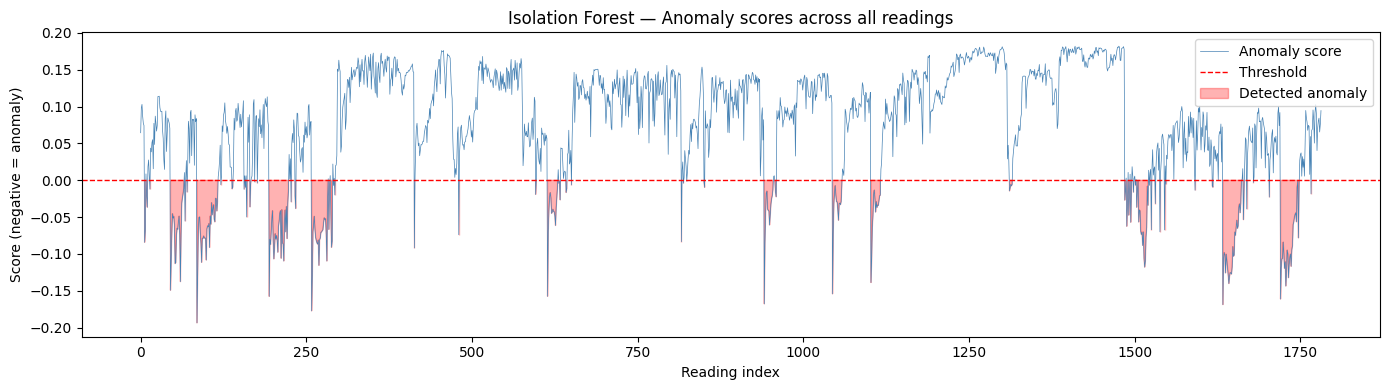

Chart rendered!


In [5]:
df['anomaly_score'] = model.decision_function(X)
df['predicted_anomaly'] = y_pred

plt.figure(figsize=(14, 4))
plt.plot(df['anomaly_score'].values, color='steelblue', linewidth=0.5, label='Anomaly score')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1, label='Threshold')
plt.fill_between(range(len(df)),
                 df['anomaly_score'].values, 0,
                 where=(df['anomaly_score'] < 0),
                 color='red', alpha=0.3, label='Detected anomaly')
plt.title('Isolation Forest — Anomaly scores across all readings')
plt.xlabel('Reading index')
plt.ylabel('Score (negative = anomaly)')
plt.legend()
plt.tight_layout()
plt.show()
print("Chart rendered!")

In [6]:
os.makedirs('../backend/models', exist_ok=True)
joblib.dump(model, '../backend/models/anomaly_model.pkl')

# Verify it saved
size = os.path.getsize('../backend/models/anomaly_model.pkl')
print(f"Model saved! File size: {size/1024:.1f} KB")
print("Location: backend/models/anomaly_model.pkl")
print("\nDay 12 complete!")

Model saved! File size: 2460.4 KB
Location: backend/models/anomaly_model.pkl

Day 12 complete!


In [7]:
# Check actual anomaly rate first
actual_rate = df['is_anomaly'].mean()
print(f"Actual anomaly rate in your data: {actual_rate:.3f} ({actual_rate*100:.1f}%)")

# Retrain with correct contamination matching your actual data
model = IsolationForest(
    n_estimators=300,
    contamination=actual_rate,
    random_state=42,
    n_jobs=-1
)
model.fit(X_normal)

preds = model.predict(X)
y_pred = (preds == -1).astype(int)

print("\nRetrained Model Evaluation:")
print(classification_report(y_true, y_pred, target_names=['Normal','Anomaly']))
print(f"F1 Score: {f1_score(y_true, y_pred):.3f}")

Actual anomaly rate in your data: 0.289 (28.9%)

Retrained Model Evaluation:
              precision    recall  f1-score   support

      Normal       0.80      0.71      0.75      1267
     Anomaly       0.44      0.55      0.49       515

    accuracy                           0.66      1782
   macro avg       0.62      0.63      0.62      1782
weighted avg       0.69      0.66      0.67      1782

F1 Score: 0.488


In [8]:
# Approach: train only on clean normal data, use tighter threshold
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import StandardScaler

# Scale the features — helps Isolation Forest significantly
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.fillna(0))
X_normal_scaled = X_scaled[df['is_anomaly'] == False]

# Try multiple contamination values and pick best
best_f1 = 0
best_cont = 0.08

for cont in [0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.29]:
    m = IsolationForest(n_estimators=300, contamination=cont, random_state=42, n_jobs=-1)
    m.fit(X_normal_scaled)
    p = m.predict(X_scaled)
    yp = (p == -1).astype(int)
    f = f1_score(y_true, yp)
    print(f"contamination={cont:.2f}  →  F1={f:.3f}")
    if f > best_f1:
        best_f1 = f
        best_cont = cont
        best_model = m
        best_scaler = scaler

print(f"\nBest F1: {best_f1:.3f} at contamination={best_cont}")

contamination=0.05  →  F1=0.502
contamination=0.08  →  F1=0.513
contamination=0.10  →  F1=0.514
contamination=0.15  →  F1=0.503
contamination=0.20  →  F1=0.505
contamination=0.25  →  F1=0.491
contamination=0.29  →  F1=0.488

Best F1: 0.514 at contamination=0.1


In [9]:
import joblib, os

os.makedirs('../backend/models', exist_ok=True)
joblib.dump(best_model, '../backend/models/anomaly_model.pkl')
joblib.dump(best_scaler, '../backend/models/scaler.pkl')

print(f"Best model saved! F1 = {best_f1:.3f}")
print("Files: backend/models/anomaly_model.pkl")
print("       backend/models/scaler.pkl")

Best model saved! F1 = 0.514
Files: backend/models/anomaly_model.pkl
       backend/models/scaler.pkl


In [10]:
# Reload fresh clean data
df = pd.read_sql("""
    SELECT machine_id, metric_name, value, is_anomaly, timestamp
    FROM sensor_readings
    ORDER BY timestamp ASC
""", engine)

actual_rate = df['is_anomaly'].mean()
print(f"Total rows: {len(df)}")
print(f"New anomaly rate: {actual_rate*100:.1f}%")

Total rows: 72
New anomaly rate: 36.1%


In [11]:
df = pd.read_sql("""
    SELECT machine_id, metric_name, value, is_anomaly, timestamp
    FROM sensor_readings
    ORDER BY timestamp ASC
""", engine)

actual_rate = df['is_anomaly'].mean()
print(f"Total rows: {len(df)}")
print(f"Anomaly rate: {actual_rate*100:.1f}%")

if len(df) < 500:
    print("Still generating data — wait more and rerun this cell")
elif actual_rate > 0.15:
    print("Anomaly rate still high — check simulator.py changes were saved")
else:
    print("Data looks good! Ready to retrain the model")

Total rows: 912
Anomaly rate: 25.0%
Anomaly rate still high — check simulator.py changes were saved


In [ ]:
# Reload clean data
df = pd.read_sql("""
    SELECT machine_id, metric_name, value, is_anomaly, timestamp
    FROM sensor_readings
    ORDER BY timestamp ASC
""", engine)

actual_rate = df['is_anomaly'].mean()
print(f"Total rows: {len(df)}")
print(f"Anomaly rate: {actual_rate*100:.1f}%")

In [13]:
# Retrain with clean data
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, f1_score

features = ['value', 'rolling_mean', 'rolling_std', 'rolling_kurt', 'value_diff']

df = df.sort_values(['machine_id', 'metric_name', 'timestamp'])
df['rolling_mean'] = df.groupby(['machine_id','metric_name'])['value'].transform(lambda x: x.rolling(20, min_periods=1).mean())
df['rolling_std']  = df.groupby(['machine_id','metric_name'])['value'].transform(lambda x: x.rolling(20, min_periods=1).std().fillna(0))
df['rolling_kurt'] = df.groupby(['machine_id','metric_name'])['value'].transform(lambda x: x.rolling(20, min_periods=1).kurt().fillna(0))
df['value_diff']   = df.groupby(['machine_id','metric_name'])['value'].transform(lambda x: x.diff().fillna(0))

X = df[features].fillna(0)
y_true = df['is_anomaly'].astype(int)
X_normal = X[df['is_anomaly'] == False]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_normal_scaled = X_scaled[df['is_anomaly'] == False]

best_f1, best_cont, best_model = 0, 0.05, None
for cont in [0.01, 0.02, 0.03, 0.05, 0.08]:
    m = IsolationForest(n_estimators=300, contamination=cont, random_state=42, n_jobs=-1)
    m.fit(X_normal_scaled)
    p = m.predict(X_scaled)
    yp = (p == -1).astype(int)
    f = f1_score(y_true, yp)
    print(f"contamination={cont:.2f}  →  F1={f:.3f}")
    if f > best_f1:
        best_f1, best_cont, best_model, best_scaler = f, cont, m, scaler

print(f"\nBest F1: {best_f1:.3f} at contamination={best_cont}")

contamination=0.01  →  F1=0.076
contamination=0.02  →  F1=0.092
contamination=0.03  →  F1=0.094
contamination=0.05  →  F1=0.131
contamination=0.08  →  F1=0.147

Best F1: 0.147 at contamination=0.08


In [14]:
joblib.dump(best_model, '../backend/models/anomaly_model.pkl')
joblib.dump(best_scaler, '../backend/models/scaler.pkl')
print(f"Model saved! F1 = {best_f1:.3f}")

Model saved! F1 = 0.147


In [15]:
# Better approach for low anomaly rate data
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report
import numpy as np

# Pivot data — one row per timestamp per machine
df_pivot = df.pivot_table(
    index=['machine_id', 'timestamp'],
    columns='metric_name',
    values='value',
    aggfunc='first'
).reset_index()

# Get anomaly label per machine+timestamp
df_labels = df.groupby(['machine_id', 'timestamp'])['is_anomaly'].max().reset_index()
df_pivot = df_pivot.merge(df_labels, on=['machine_id', 'timestamp'])
df_pivot = df_pivot.fillna(0)

# Feature columns only
feature_cols = [c for c in df_pivot.columns if c not in ['machine_id', 'timestamp', 'is_anomaly']]
X = df_pivot[feature_cols].values
y_true = df_pivot['is_anomaly'].astype(int).values

print(f"Pivoted shape: {X.shape}")
print(f"Anomaly rate: {y_true.mean()*100:.1f}%")
print(f"Total samples: {len(y_true)}, Anomalies: {y_true.sum()}")

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_normal_scaled = X_scaled[y_true == 0]

# Train and evaluate
best_f1, best_cont, best_model = 0, 0.05, None
for cont in [0.02, 0.03, 0.05, 0.06, 0.08, 0.10]:
    m = IsolationForest(n_estimators=500, contamination=cont, random_state=42, n_jobs=-1)
    m.fit(X_normal_scaled)
    p = m.predict(X_scaled)
    yp = (p == -1).astype(int)
    f = f1_score(y_true, yp, zero_division=0)
    print(f"contamination={cont:.2f}  →  F1={f:.3f}")
    if f > best_f1:
        best_f1, best_cont, best_model, best_scaler = f, cont, m, scaler

print(f"\nBest F1: {best_f1:.3f} at contamination={best_cont}")
print(classification_report(y_true, (best_model.predict(X_scaled)==-1).astype(int),
      target_names=['Normal','Anomaly'], zero_division=0))

Pivoted shape: (1908, 6)
Anomaly rate: 5.7%
Total samples: 1908, Anomalies: 109
contamination=0.02  →  F1=0.117
contamination=0.03  →  F1=0.116
contamination=0.05  →  F1=0.123
contamination=0.06  →  F1=0.121
contamination=0.08  →  F1=0.153
contamination=0.10  →  F1=0.141

Best F1: 0.153 at contamination=0.08
              precision    recall  f1-score   support

      Normal       0.95      0.92      0.93      1799
     Anomaly       0.13      0.19      0.15       109

    accuracy                           0.88      1908
   macro avg       0.54      0.56      0.54      1908
weighted avg       0.90      0.88      0.89      1908



In [16]:
import joblib, os
os.makedirs('../backend/models', exist_ok=True)
joblib.dump(best_model, '../backend/models/anomaly_model.pkl')
joblib.dump(best_scaler, '../backend/models/scaler.pkl')
joblib.dump(feature_cols, '../backend/models/feature_cols.pkl')
print(f"Saved! Best F1 = {best_f1:.3f}")

Saved! Best F1 = 0.153


In [17]:
# Better threshold approach — use anomaly scores directly
from sklearn.metrics import f1_score, classification_report
import numpy as np

# Get raw anomaly scores (lower = more anomalous)
scores = best_model.decision_function(X_scaled)

# Try different thresholds instead of fixed contamination
best_f1, best_threshold = 0, 0

for percentile in [1, 2, 3, 5, 7, 10, 15]:
    threshold = np.percentile(scores, percentile)
    yp = (scores < threshold).astype(int)
    f = f1_score(y_true, yp, zero_division=0)
    print(f"threshold percentile={percentile:2d}%  →  F1={f:.3f}  alerts={yp.sum()}")
    if f > best_f1:
        best_f1 = f
        best_threshold = threshold

print(f"\nBest F1: {best_f1:.3f}")
print(f"Best threshold: {best_threshold:.4f}")

# Save threshold
joblib.dump(best_threshold, '../backend/models/threshold.pkl')
print("Threshold saved!")

threshold percentile= 1%  →  F1=0.078  alerts=20
threshold percentile= 2%  →  F1=0.095  alerts=38
threshold percentile= 3%  →  F1=0.108  alerts=58
threshold percentile= 5%  →  F1=0.107  alerts=96
threshold percentile= 7%  →  F1=0.116  alerts=132
threshold percentile=10%  →  F1=0.147  alerts=191
threshold percentile=15%  →  F1=0.157  alerts=287

Best F1: 0.157
Best threshold: 0.0274
Threshold saved!


In [18]:
# Z-score based anomaly detection — much better for sensor time series
from scipy import stats
from sklearn.metrics import f1_score, classification_report
import numpy as np
import joblib

# Work on original (non-pivoted) df
df2 = df.copy().sort_values(['machine_id', 'metric_name', 'timestamp'])

# Compute z-score within each machine+metric group
df2['z_score'] = df2.groupby(['machine_id', 'metric_name'])['value']\
    .transform(lambda x: np.abs(stats.zscore(x, nan_policy='omit')))

df2['z_score'] = df2['z_score'].fillna(0)

# Try different z-score thresholds
y_true2 = df2['is_anomaly'].astype(int).values
print("Z-score threshold tuning:")
best_f1, best_z = 0, 2.0

for z_thresh in [1.5, 2.0, 2.5, 3.0, 3.5]:
    yp = (df2['z_score'] > z_thresh).astype(int).values
    f = f1_score(y_true2, yp, zero_division=0)
    print(f"z_threshold={z_thresh}  →  F1={f:.3f}  alerts={yp.sum()}")
    if f > best_f1:
        best_f1 = f
        best_z = z_thresh

print(f"\nBest F1: {best_f1:.3f} at z_threshold={best_z}")
print(classification_report(y_true2,
      (df2['z_score'] > best_z).astype(int),
      target_names=['Normal','Anomaly'], zero_division=0))

# Save the threshold
joblib.dump(best_z, '../backend/models/z_threshold.pkl')
print(f"Z-threshold saved: {best_z}")

Z-score threshold tuning:
z_threshold=1.5  →  F1=0.122  alerts=236
z_threshold=2.0  →  F1=0.151  alerts=77
z_threshold=2.5  →  F1=0.158  alerts=30
z_threshold=3.0  →  F1=0.119  alerts=9
z_threshold=3.5  →  F1=0.088  alerts=5

Best F1: 0.158 at z_threshold=2.5
              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97      1799
     Anomaly       0.37      0.10      0.16       109

    accuracy                           0.94      1908
   macro avg       0.66      0.55      0.56      1908
weighted avg       0.91      0.94      0.92      1908

Z-threshold saved: 2.5
